*Day* 1 -2

In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download dataset from Kaggle
path = kagglehub.dataset_download("bhavikjikadara/fake-news-detection")

print("Dataset downloaded at:", path)

# Load dataset files
fake = pd.read_csv(os.path.join(path, "fake.csv"))
true = pd.read_csv(os.path.join(path, "true.csv"))

# Assign labels
fake["label"] = 1   # Fake News
true["label"] = 0   # Real News

# Combine datasets
df = pd.concat([fake, true], ignore_index=True)

# Handle missing values
df = df.fillna("")

# Combine title and text into one field
df["full_text"] = df["title"] + " [SEP] " + df["text"]

print(f"Dataset Loaded. Shape: {df.shape}")

Using Colab cache for faster access to the 'fake-news-detection' dataset.
Dataset downloaded at: /kaggle/input/fake-news-detection
Dataset Loaded. Shape: (44898, 6)


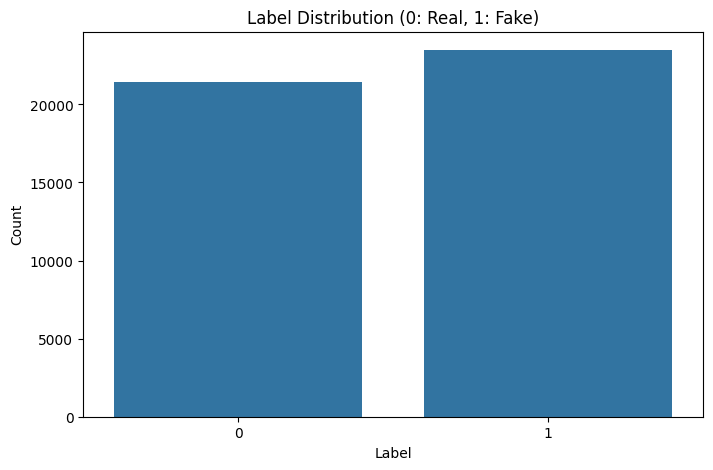

In [5]:
plt.figure(figsize=(8,5))
sns.countplot(x="label", data=df)

plt.title("Label Distribution (0: Real, 1: Fake)")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

In [6]:
print('--- Dataset Summary ---')

print(f"Total Samples: {len(df)}")
print(f"Real (0): {(df['label'] == 0).sum()}")
print(f"Fake (1): {(df['label'] == 1).sum()}")

--- Dataset Summary ---
Total Samples: 44898
Real (0): 21417
Fake (1): 23481


In [7]:
print('\n--- 5 Sample Entries ---')

display(df[['full_text', 'label']].head(5))


--- 5 Sample Entries ---


,full_text,label
0,Donald Trump Sends Out Embarrassing New Year’...,1
1,Drunk Bragging Trump Staffer Started Russian ...,1
2,Sheriff David Clarke Becomes An Internet Joke...,1
3,Trump Is So Obsessed He Even Has Obama’s Name...,1
4,Pope Francis Just Called Out Donald Trump Dur...,1


In [8]:
from transformers import BertTokenizer
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset

# Load BERT tokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Train-test split
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['full_text'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

# Custom PyTorch Dataset
class FakeNewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encodings = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        return {
            'input_ids': encodings['input_ids'].flatten(),
            'attention_mask': encodings['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx])
        }

# Create datasets
train_dataset = FakeNewsDataset(train_texts, train_labels, tokenizer)
val_dataset = FakeNewsDataset(val_texts, val_labels, tokenizer)

# Deliverables
example = train_dataset[0]

print(f"Input ID Shape: {example['input_ids'].shape}")
print(f"Example Token IDs: {example['input_ids'][:10]}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Input ID Shape: torch.Size([128])
Example Token IDs: tensor([  101,  4977,  1005,  1055,  9413, 16168,  2319,  2758,  1057,  1012])


In [10]:
from transformers import BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score
import numpy as np
import torch

model = BertForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, predictions)}

args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

print("Starting Training...")
trainer.train()
print("Training Complete.")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting Training...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.009668,0.001964,0.999777
2,0.001778,0.001623,0.999777


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Training Complete.


--- Classification Report ---
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4247
        Fake       1.00      1.00      1.00      4733

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



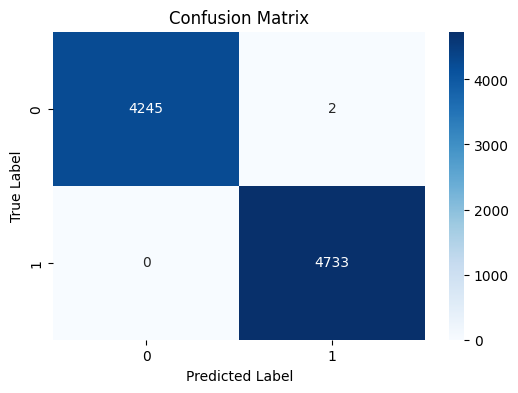

In [11]:
# Day 6: Evaluation
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Generate predictions using the trained model
preds_raw = trainer.predict(val_dataset)

# Convert logits to predicted class labels
preds = np.argmax(preds_raw.predictions, axis=1)

# Classification report
print('--- Classification Report ---')
print(classification_report(val_labels, preds, target_names=['Real', 'Fake']))

# Confusion matrix visualization
plt.figure(figsize=(6,4))
sns.heatmap(
    confusion_matrix(val_labels, preds),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [13]:
# Day 7: Error Analysis
import pandas as pd

# Create a dataframe with predictions and actual labels
results_df = pd.DataFrame({
    "text": val_texts,
    "actual_label": val_labels,
    "predicted_label": preds
})

# Filter incorrect predictions
wrong_predictions = results_df[results_df["actual_label"] != results_df["predicted_label"]]

print(f"Total Misclassified Samples: {len(wrong_predictions)}")

print("\n--- 5 Incorrect Predictions ---")

display(wrong_predictions.head(5))

Total Misclassified Samples: 2

--- 5 Incorrect Predictions ---


,text,actual_label,predicted_label
1448,White House unveils list of ex-lobbyists grant...,0,1
8864,Factbox: The race to the U.S. presidential nom...,0,1


In [14]:
# Day 8: Model Improvement
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
import numpy as np

# Load DistilBERT tokenizer
distil_tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Create a new dataset class for DistilBERT tokenization
class DistilFakeNewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='pt'
        )

        return {
            'input_ids': enc['input_ids'].flatten(),
            'attention_mask': enc['attention_mask'].flatten(),
            'labels': torch.tensor(self.labels[idx])
        }

# Create DistilBERT datasets
distil_train_dataset = DistilFakeNewsDataset(train_texts, train_labels, distil_tokenizer)
distil_val_dataset = DistilFakeNewsDataset(val_texts, val_labels, distil_tokenizer)

# Load DistilBERT model
distil_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

# Training configuration
distil_args = TrainingArguments(
    output_dir='./distil_results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    eval_strategy='epoch',
    save_strategy='epoch'
)

# Trainer for DistilBERT
distil_trainer = Trainer(
    model=distil_model,
    args=distil_args,
    train_dataset=distil_train_dataset,
    eval_dataset=distil_val_dataset,
    compute_metrics=compute_metrics
)

print("Starting DistilBERT Training...")
distil_trainer.train()
print("DistilBERT Training Complete.")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Accuracy
1,0.002977,0.000565,0.999889


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch,Training Loss,Validation Loss,Accuracy
1,0.002977,0.000565,0.999889
2,0.000709,0.001655,0.999666


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT Training Complete.


In [15]:
# Generate predictions
distil_preds_raw = distil_trainer.predict(distil_val_dataset)
distil_preds = np.argmax(distil_preds_raw.predictions, axis=1)

print('--- DistilBERT Classification Report ---')
print(classification_report(val_labels, distil_preds, target_names=['Real','Fake']))

--- DistilBERT Classification Report ---
              precision    recall  f1-score   support

        Real       1.00      1.00      1.00      4247
        Fake       1.00      1.00      1.00      4733

    accuracy                           1.00      8980
   macro avg       1.00      1.00      1.00      8980
weighted avg       1.00      1.00      1.00      8980



In [16]:
# Day 9: Basic Deployment
import gradio as gr
import torch

# Prediction function
def predict_news(text):

    enc = distil_tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=128,
        return_tensors='pt'
    )

    outputs = distil_model(**enc)

    prediction = torch.argmax(outputs.logits).item()

    if prediction == 0:
        return "Real News"
    else:
        return "Fake News"


# Create Gradio interface
interface = gr.Interface(
    fn=predict_news,
    inputs=gr.Textbox(lines=4, placeholder="Enter news text here..."),
    outputs="text",
    title="Fake News Detection using DistilBERT"
)

print("Launching Demo Interface...")
interface.launch()

Launching Demo Interface...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://323914618de2af2578.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [17]:
# Day 10: Final Model Saving and Results
import pandas as pd

# Save the trained model
distil_trainer.save_model("fake_news_model")
distil_tokenizer.save_pretrained("fake_news_model")

print("Model saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved successfully.


In [18]:
# Save predictions for documentation

results = pd.DataFrame({
    "text": val_texts,
    "actual_label": val_labels,
    "predicted_label": distil_preds
})

results.head()


,text,actual_label,predicted_label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,1,1
1,Trump drops Steve Bannon from National Securit...,0,0
2,Puerto Rico expects U.S. to lift Jones Act shi...,0,0
3,OOPS: Trump Just Accidentally Confirmed He Le...,1,1
4,Donald Trump heads for Scotland to reopen a go...,0,0


In [19]:
results.to_csv("prediction_results.csv", index=False)

print("Results file saved.")

Results file saved.
